In [4]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from peptigraph.core.protbert_sequence_classifier import ProtBertSequenceClassifier

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# PROBERT

Generally, ProBERT itself is not a classification model.

It serves as a tool for sequence embedding (provided as a string like ABGSAYD etc.). It's an alternative to data processing for scikit-fingerprints.

According to the literature, such embedding contains information about:
* physicochemical properties of amino acids
* sequence patterns
* potential functional motifs
* relationships between positions in the sequence

In [5]:
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert")
model = model.to(device)
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30, 1024, padding_idx=0)
    (position_embeddings): Embedding(40000, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-29): 30 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.0, i

In [ ]:
classifier = ProtBertSequenceClassifier(tokenizer=tokenizer, model=model)

In [6]:
print("\nAnalyzing HemoPI-1")
print("-" * 50)

df_hemo1 = pd.read_csv('C:\Python\semestr_1\PeptiGraph\data\smiles\hemopi_1.csv')
X = df_hemo1['sequence'].values
y = df_hemo1['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_embeddings = classifier._get_embeddings(X_train)
X_test_embeddings = classifier._get_embeddings(X_test)

clf = RandomForestClassifier(n_estimators=400, max_depth=20, random_state=42)
clf.fit(X_train_embeddings, y_train)
y_pred = clf.predict(X_test_embeddings)
y_pred_proba = clf.predict_proba(X_test_embeddings)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auroc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)

print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

if device.type == 'cuda':
    torch.cuda.empty_cache()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Analyzing HemoPI-1
--------------------------------------------------
AUROC: 0.975
AUPRC: 0.978

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        89
           1       0.95      0.88      0.91        88

    accuracy                           0.92       177
   macro avg       0.92      0.92      0.92       177
weighted avg       0.92      0.92      0.92       177



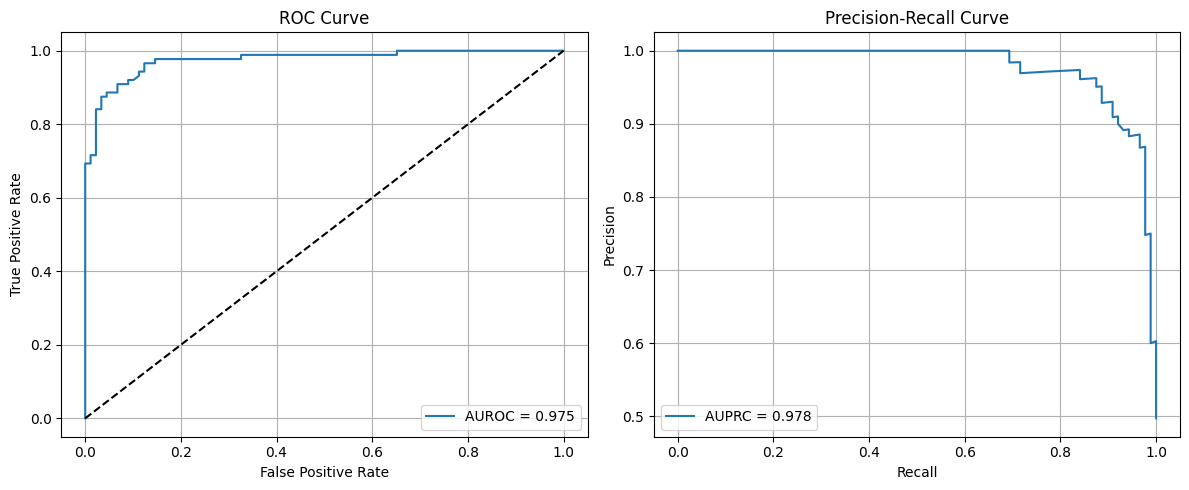

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

if device.type == 'cuda':
    torch.cuda.empty_cache()

In [8]:
print("\nAnalyzing HemoPI-2")
print("-" * 50)

df_hemo2 = pd.read_csv('C:\Python\semestr_1\PeptiGraph\data\smiles\hemopi_2.csv')
X = df_hemo2['sequence'].values
y = df_hemo2['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_embeddings = get_embeddings(X_train, tokenizer, model)
X_test_embeddings = get_embeddings(X_test, tokenizer, model)

clf = RandomForestClassifier(n_estimators=400, max_depth=20, random_state=42)
clf.fit(X_train_embeddings, y_train)
y_pred = clf.predict(X_test_embeddings)
y_pred_proba = clf.predict_proba(X_test_embeddings)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auroc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)

print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

if device.type == 'cuda':
    torch.cuda.empty_cache()


Analyzing HemoPI-2
--------------------------------------------------
AUROC: 0.831
AUPRC: 0.811

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76        74
           1       0.80      0.79      0.80        89

    accuracy                           0.78       163
   macro avg       0.78      0.78      0.78       163
weighted avg       0.78      0.78      0.78       163



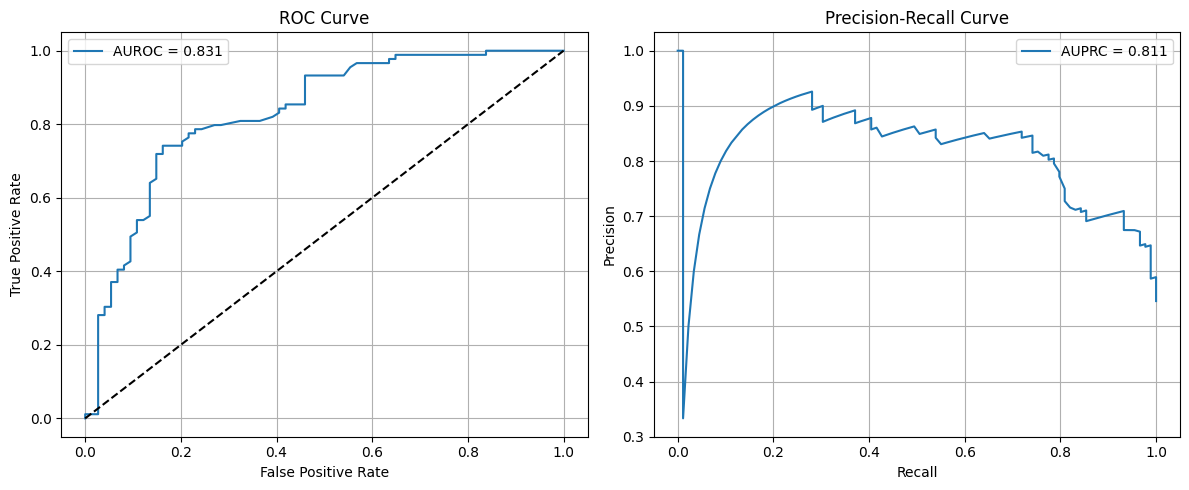

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

if device.type == 'cuda':
    torch.cuda.empty_cache()

In [10]:
print("\nAnalyzing HemoPI-3")
print("-" * 50)

df_hemo3= pd.read_csv('C:\Python\semestr_1\PeptiGraph\data\smiles\hemopi_3.csv')
X = df_hemo3['sequence'].values
y = df_hemo3['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_embeddings = get_embeddings(X_train, tokenizer, model)
X_test_embeddings = get_embeddings(X_test, tokenizer, model)

clf = RandomForestClassifier(n_estimators=400, max_depth=20, random_state=42)
clf.fit(X_train_embeddings, y_train)
y_pred = clf.predict(X_test_embeddings)
y_pred_proba = clf.predict_proba(X_test_embeddings)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auroc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)

print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

if device.type == 'cuda':
    torch.cuda.empty_cache()


Analyzing HemoPI-3
--------------------------------------------------
AUROC: 0.862
AUPRC: 0.853

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       148
           1       0.82      0.75      0.78       142

    accuracy                           0.80       290
   macro avg       0.80      0.80      0.80       290
weighted avg       0.80      0.80      0.80       290



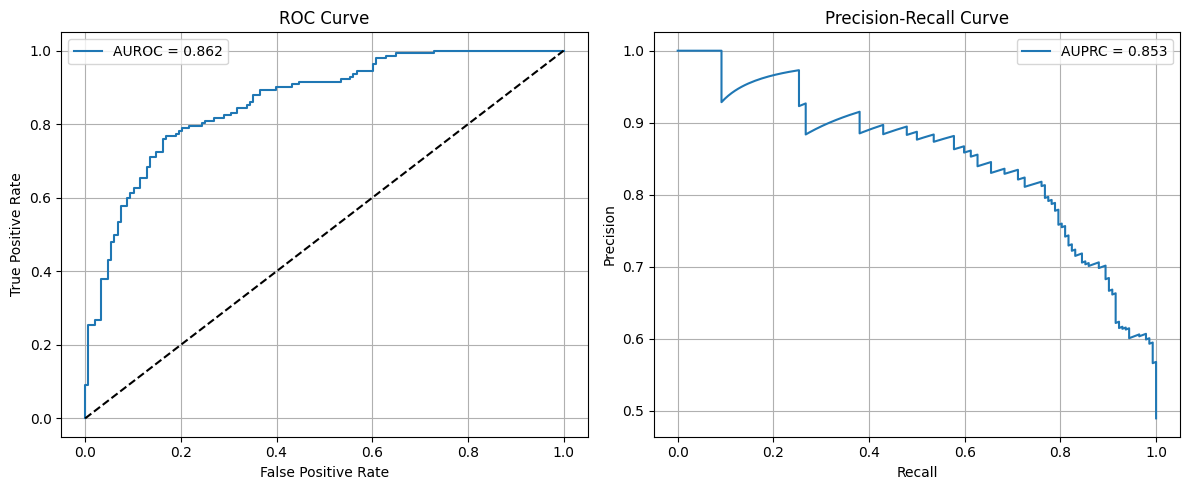

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

if device.type == 'cuda':
    torch.cuda.empty_cache()